In [55]:
#Importação de bibliotecas para tratamento dos dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [56]:
#Leitura da base de dados Base_RH com 1470 funcionários
df = pd.read_csv('Base_RH_final.csv',sep=';')

In [68]:
#Entendendo os dados
print('Linhas e Colunas: ',df.shape)
#print(df.head())
print('Títulos das colunas: ',df.columns)

#Resumo das variáveis
print(df.info())

#Checando duplicidades
print('Duplicados: ', df.duplicated().sum())

df.describe()

Linhas e Colunas:  (1470, 21)
Títulos das colunas:  Index(['ID', 'Funcionário_deixou_a_empresa', 'Idade', 'Frequência de Viagens',
       'Distância_do_trabalho', 'Formação', 'E-Sat', 'Gênero', 'Estado_Civil',
       'Salário', 'Qte_Empresas_Trabalhadas', 'Faz_hora_extras?',
       'Perc_de_aumento', 'Qte_ações_da_empresa', 'Tempo_de_carreira',
       'Horas_de_treinamento', 'Equilibrio_de_Vida', 'Tempo_de_empresa',
       'Anos_no_mesmo_cargo', 'Anos_desde_a_ultima_promocao',
       'Anos_com_o_mesmo_chefe'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   ID                            1470 non-null   int64 
 1   Funcionário_deixou_a_empresa  1470 non-null   object
 2   Idade                         1470 non-null   int64 
 3   Frequência de Viagens         1470 non-null   object
 4   Di

,ID,Idade,Distância_do_trabalho,Salário,Qte_Empresas_Trabalhadas,Perc_de_aumento,Qte_ações_da_empresa,Tempo_de_carreira,Horas_de_treinamento,Tempo_de_empresa,Anos_no_mesmo_cargo,Anos_desde_a_ultima_promocao,Anos_com_o_mesmo_chefe
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,9.192517,6502.931293,2.693197,15.209524,0.793878,11.279592,2.799320,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,8.106864,4707.956783,2.498009,3.659938,0.852077,7.780782,1.289271,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,1.000000,1009.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,2.000000,2911.000000,1.000000,12.000000,0.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,7.000000,4919.000000,2.000000,14.000000,1.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,14.000000,8379.000000,4.000000,18.000000,1.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,29.000000,19999.000000,9.000000,25.000000,3.000000,40.000000,6.000000,40.000000,18.000000,15.000000,17.000000


In [76]:
col_num = [feature for feature in df.columns if df[feature].dtype != 'O']
col_cat = [feature for feature in df.columns if df[feature].dtype == 'O']

### print columns
print(f"Temos {len(col_num)} colunas numéricas: {col_num}")
print(f"Temos {len(col_cat)} colunas categóricas: {col_cat}")

Temos 13 colunas numéricas: ['ID', 'Idade', 'Distância_do_trabalho', 'Salário', 'Qte_Empresas_Trabalhadas', 'Perc_de_aumento', 'Qte_ações_da_empresa', 'Tempo_de_carreira', 'Horas_de_treinamento', 'Tempo_de_empresa', 'Anos_no_mesmo_cargo', 'Anos_desde_a_ultima_promocao', 'Anos_com_o_mesmo_chefe']
Temos 8 colunas categóricas: ['Funcionário_deixou_a_empresa', 'Frequência de Viagens', 'Formação', 'E-Sat', 'Gênero', 'Estado_Civil', 'Faz_hora_extras?', 'Equilibrio_de_Vida']


Report inicial:
1) Dataset com 1470 observações, 21 variáveis
2) Não há observações com valores missing / nulos
3) Das 20 variáveis, 12 são numéricas e 8 são categóricas

<Axes: title={'center': 'Distância_do_trabalho'}, xlabel='Funcionário_deixou_a_empresa'>

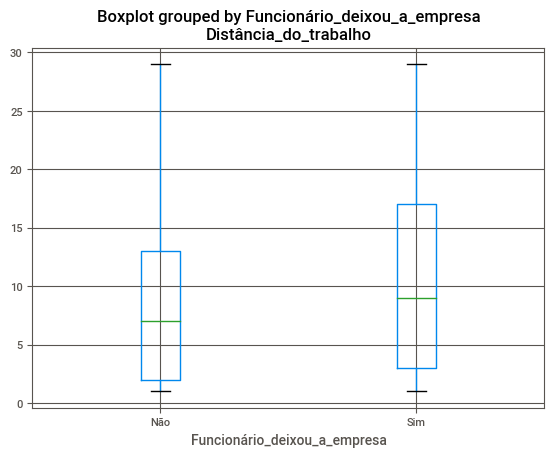

In [148]:
df.boxplot(by="Funcionário_deixou_a_empresa",column=['Distância_do_trabalho'])

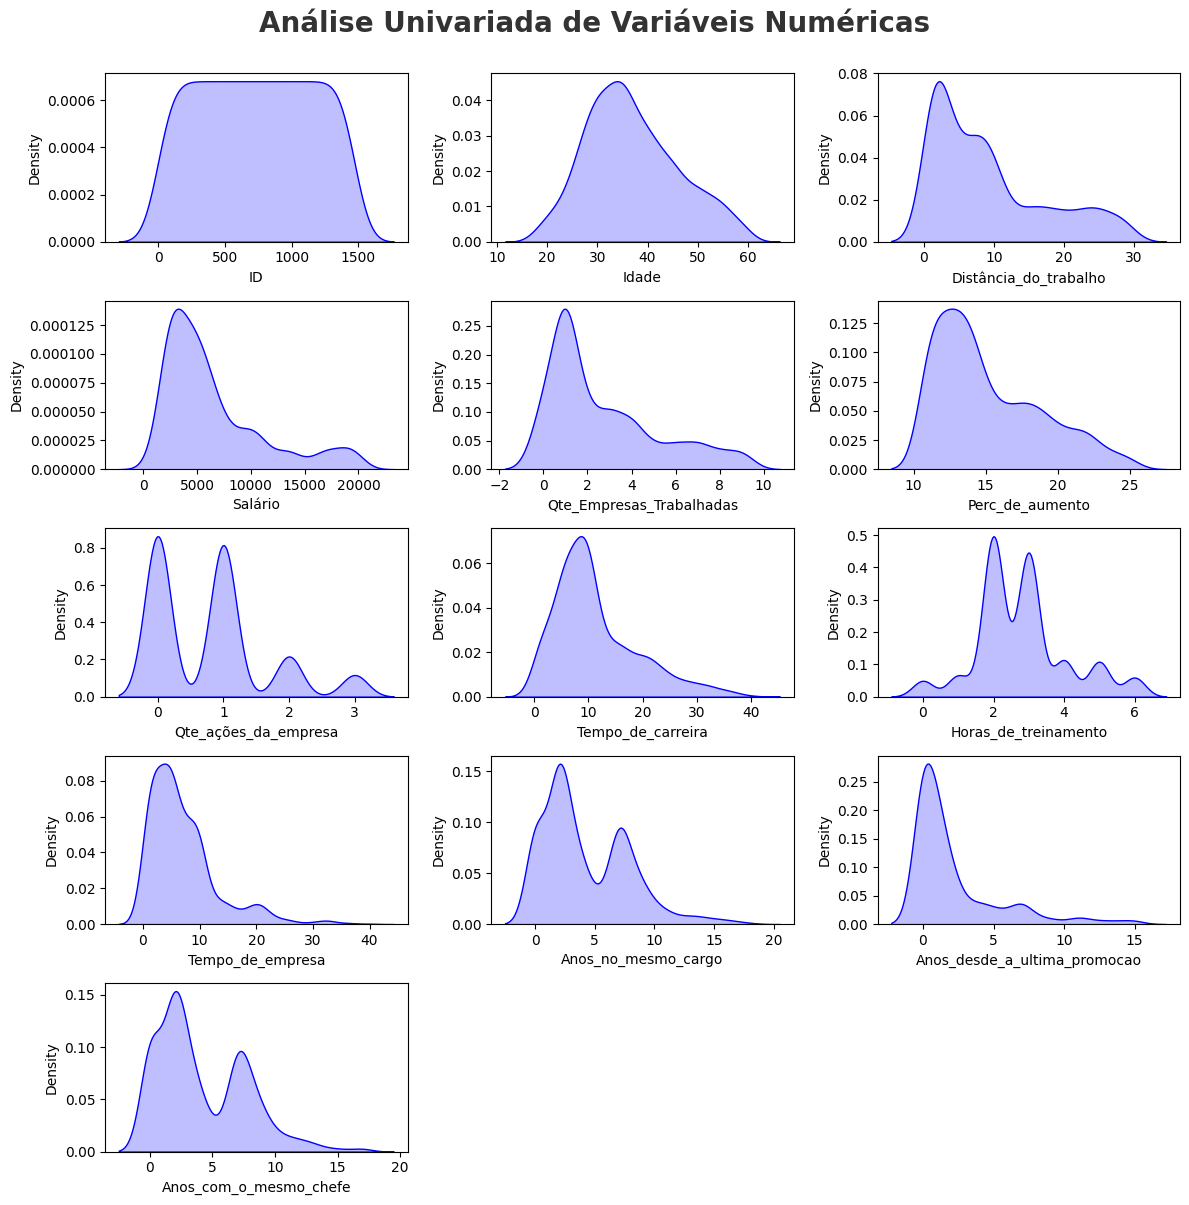

In [107]:
plt.figure(figsize=(12,12))
plt.suptitle('Análise Univariada de Variáveis Numéricas', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(len(col_num)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df[col_num[i]],shade=True,color='b')
    plt.xlabel(col_num[i])
    plt.tight_layout()

In [147]:
# Esse módulo serve para mostrar vários Pandas Data Frames de uma vez (vamos usar isso no loop da célula abaixo)
from IPython.display import display

#define função que calcula as frequências abs e rel em um novo dataframe, recebendo a variável desejada como parâmetro
#Aspas simples quando define a chave na chamada do pd.dataframe, aspas duplas quando instancia direto na variável
def frequencias(df,var):
    df3 = pd.DataFrame({'Freq Abs': df[var].value_counts()})
    df3["Freq Relativa"] = df3/df2.shape[0]
    display(df3)

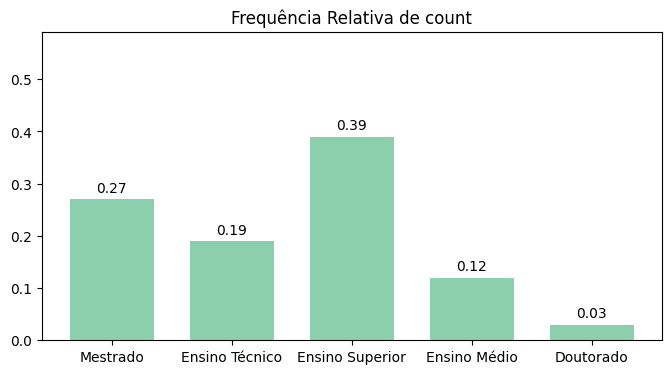

In [134]:
def tabela_bivariada(data,var):
    
    df_tab = pd.DataFrame(data[var].value_counts()).sort_values(by=var,ascending=False)
    total = df_tab.sum()
    df_tab['Freq_Relativa'] = (df_tab/total).round(decimals=2)
    df_tab['Freq_Acumulada'] = df_tab['Freq_Relativa'].cumsum().round(decimals=2)
    return df_tab;

def cria_grafico_var_qualitativa(tab):

    # Aumenta o tamanho do gráfico (largura 8 e altura 4)
    fig = plt.figure(figsize=(8,4))

    # Cria um gráfico de barras usando o indice da tabela como rótulos do eixo X
    cor = np.random.rand(3)
    plt.bar(tab.index,tab['Freq_Relativa'],width = 0.7, tick_label=tab.index,color=cor,alpha=0.6)

    plt.ylim(0,tab['Freq_Relativa'].max()+0.2)
    plt.title("Frequência Relativa de {}".format(list(tab.columns)[0]))

    # cria um conjunto de pares de rótulos e frequencias relativas
    for x,y in zip(tab.index,tab['Freq_Relativa']):

        # formata o rotulo do percentual
        rotulo = "{:.2f}".format(y)

        # coloca o rotulo na posição (x,y), alinhado ao centro e com distância 0,5 do ponto (x,y)
        plt.annotate(rotulo,(x,y),ha='center',textcoords="offset points",xytext=(0,5))

# Exemplo de uso:
tab = tabela_bivariada(df,'Formação')
cria_grafico_var_qualitativa(tab)

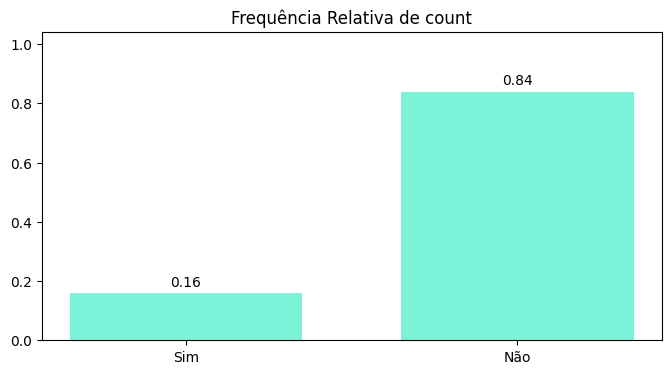

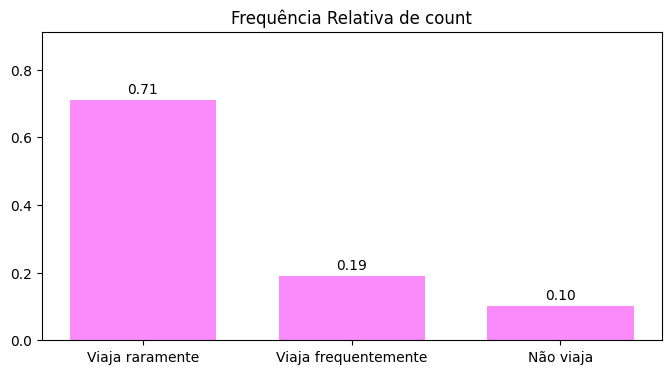

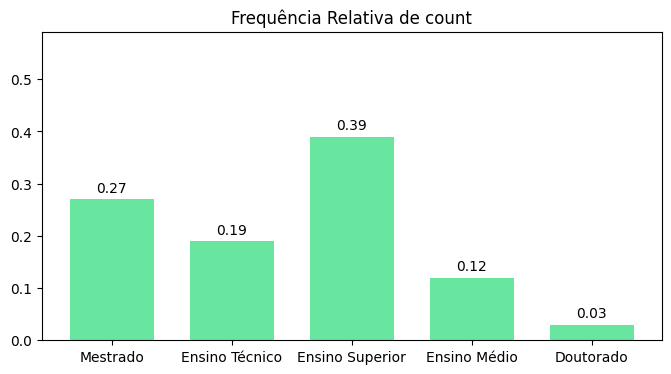

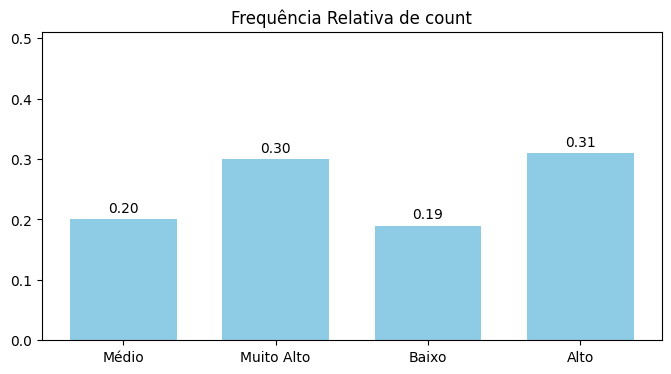

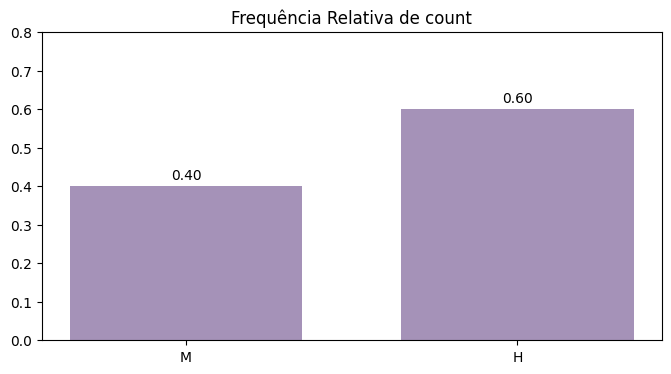

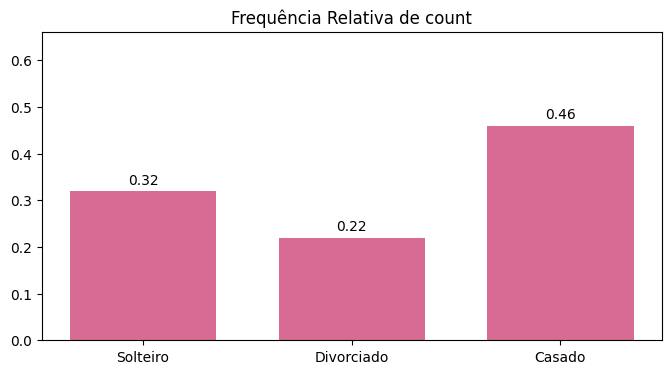

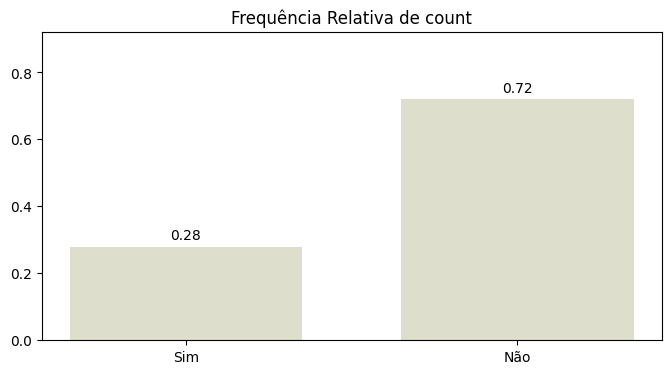

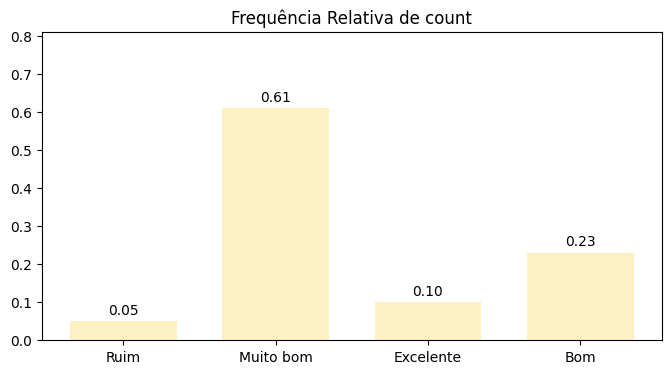

In [135]:
# Filtra o dataframe com variáveis qualitativas
df_qualitativas = df.loc[:,((df.dtypes == 'object') | 
                                (df.dtypes == 'category') |
                                (df.dtypes == 'bool'))]

for var in df_qualitativas:
    tab = tabela_bivariada(df,var)
    cria_grafico_var_qualitativa(tab)

In [137]:
def cria_grafico_var_quantitativa(df,var):

    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,3))

    # Cria um gráfico de histograma
    cor = np.random.rand(3)
    ax1.hist(df[var],bins=15, color=cor,alpha=0.4)
    ax1.title.set_text("Histograma de {}".format(var))

    # Cria um gráfico de boxplot
    ax2.boxplot(df[var])
    ax2.title.set_text("Boxplot de {}".format(var))

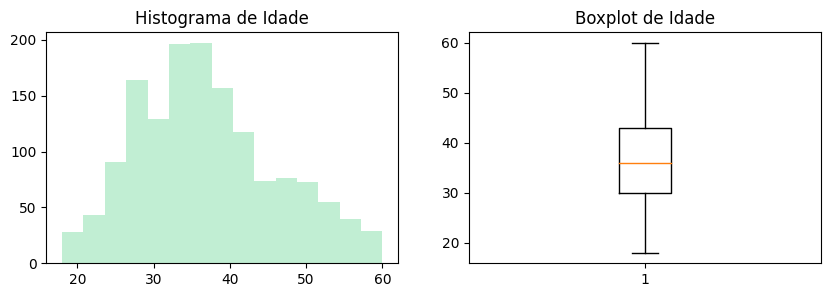

In [138]:
# Exemplo de uso:
cria_grafico_var_quantitativa(df,"Idade")

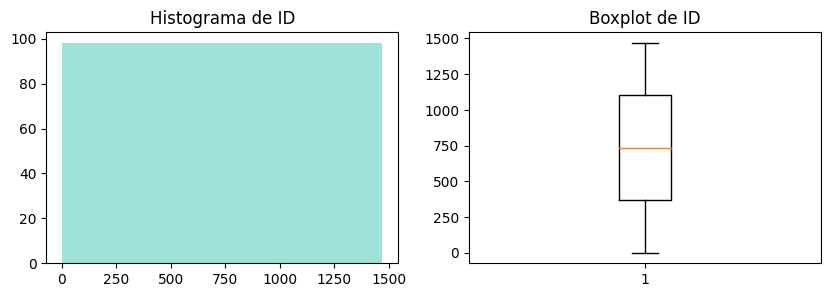

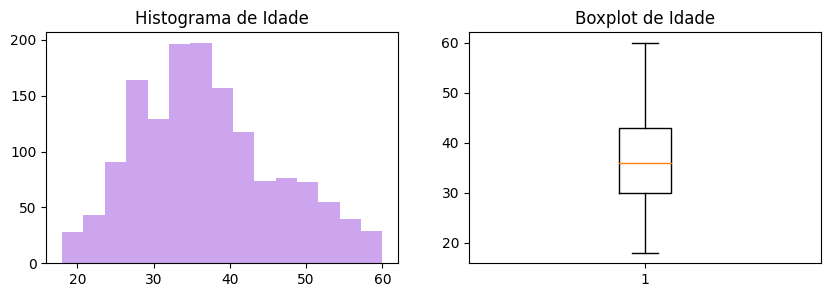

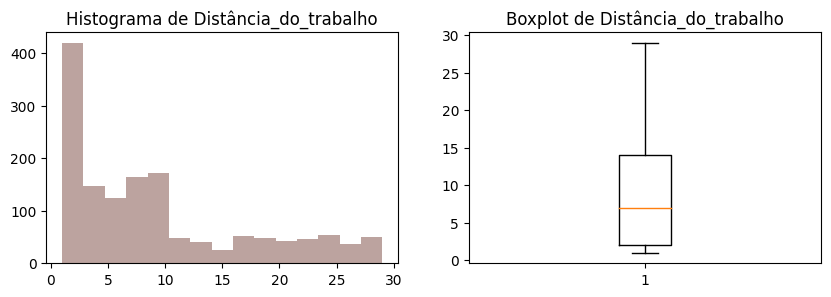

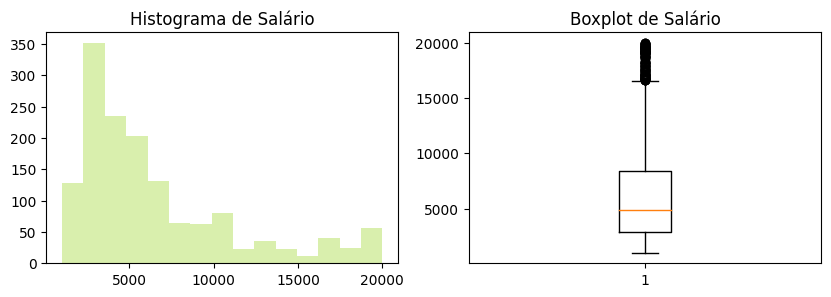

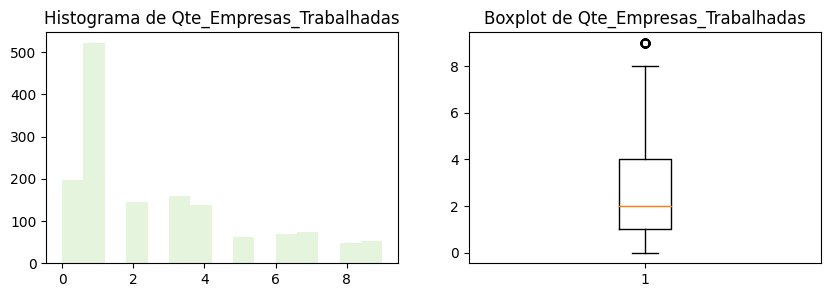

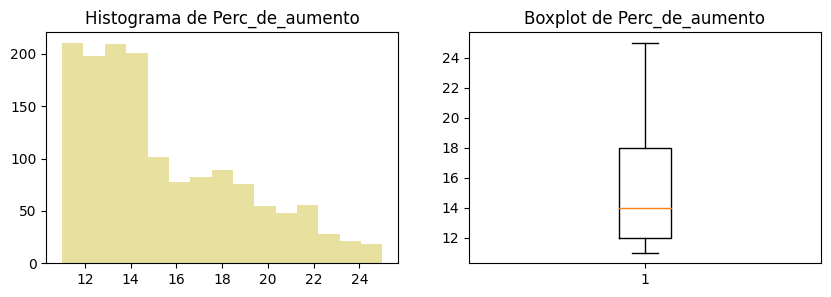

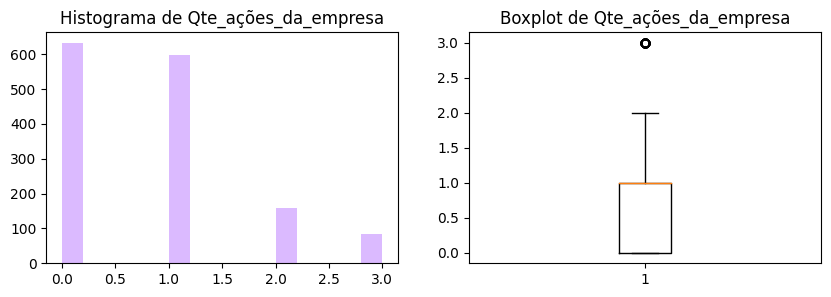

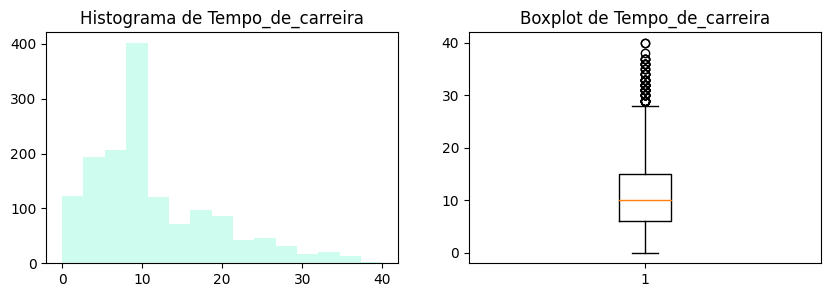

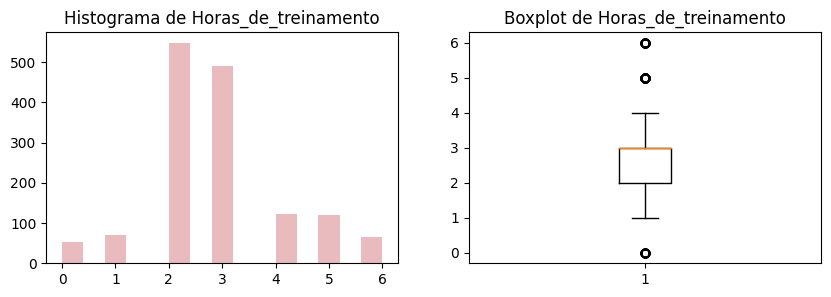

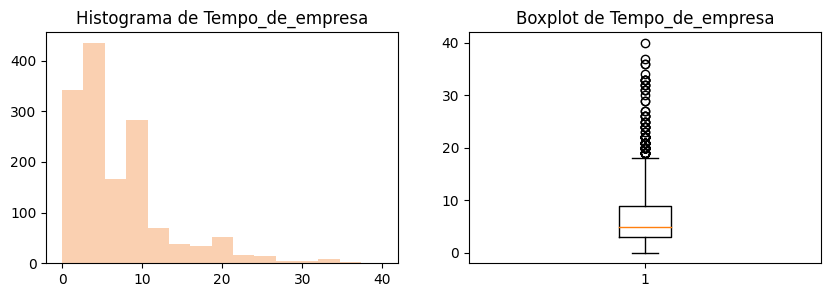

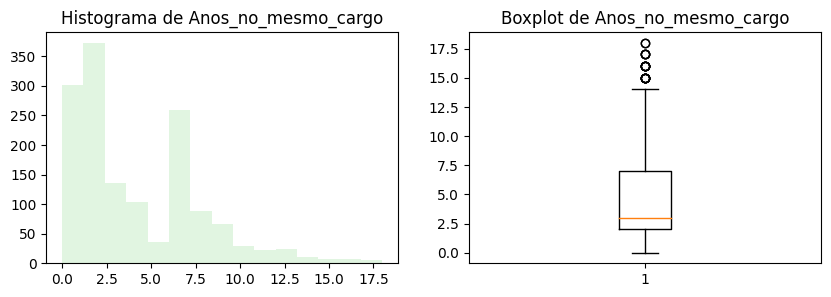

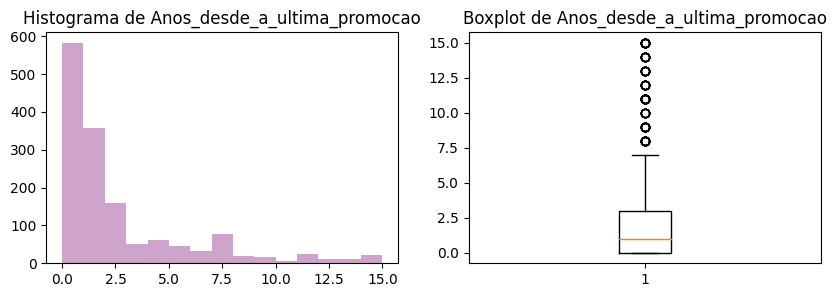

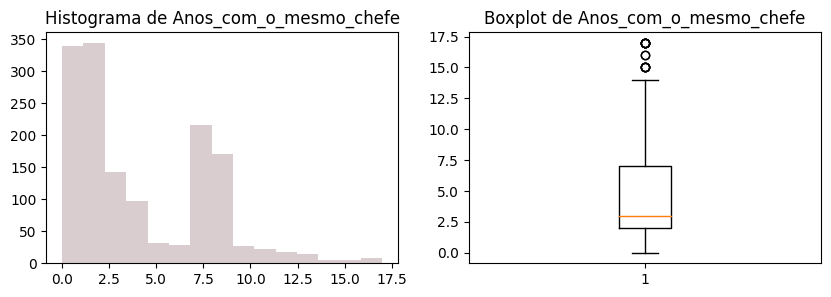

In [139]:
# Filtra o dataframe com variáveis quantitativas
df_quanti = df.loc[:,((df.dtypes == 'int64') | 
                                (df.dtypes == 'int32') |
                                (df.dtypes == 'float32') | (df.dtypes == 'float64'))]

for var in df_quanti:
    cria_grafico_var_quantitativa(df,var)

In [146]:
# Instale o pacote em seu ambiente virtual com "pip install sweetviz"
import sweetviz as sv

# Executa o Data Profiling
aed_sv = sv.analyze(df, 
                    target_feat='Distância_do_trabalho')

# Salva o arquivo HTML final com o relatório
aed_sv.show_html('aed_sv.html')

Feature: Formação (TARGET)                   |█████████▋                                                                                                | [  9%]   09:30 -> (1:35:05 left)
Done! Use 'show' commands to display/save.   |████████████████████████████████████████████████████████████████████████████████████████████████████████████| [100%]   00:00 -> (00:00 left)


Report aed_sv.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [144]:
# Instale o pacote em seu ambiente virtual com "pip install pandas_profiling".
# Instalar também o ydata-profiling -- pip install ydata-profiling
from ydata_profiling import ProfileReport

# Generate the data profiling report 
report = ProfileReport(df, title='My Data')
report.to_file("my_report.html")

# Código anterior que gerava erro ao executar

# import pandas_profiling

# Executa Data Profiling
# aed_pp = df_completa.profile_report()

# Salva o arquivo HTML final com o relatório
# aed_pp.to_file(output_file="aed_pp.html")

Summarize dataset: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 174/174 [00:13<00:00, 13.00it/s, Completed]

Generate report structure: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.38s/it]

Render HTML: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.73s/it]

Export report to file: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 116.54it/s]


In [83]:
# Esse módulo serve para mostrar vários Pandas Data Frames de uma vez
from IPython.display import display

#Define a função que calcula as frequências Absoluta e Relativa em um novo dataframe, recebendo a variável desejada como parâmetro
#Aspas simples quando define a chave na chamada do pd.dataframe, aspas duplas quando instancia direto na variável
def frequencias(df,var):
    df3 = pd.DataFrame({'Freq Abs': df[var].value_counts()})
    df3["Freq Relativa"] = df3/df2.shape[0]
    display(df3)

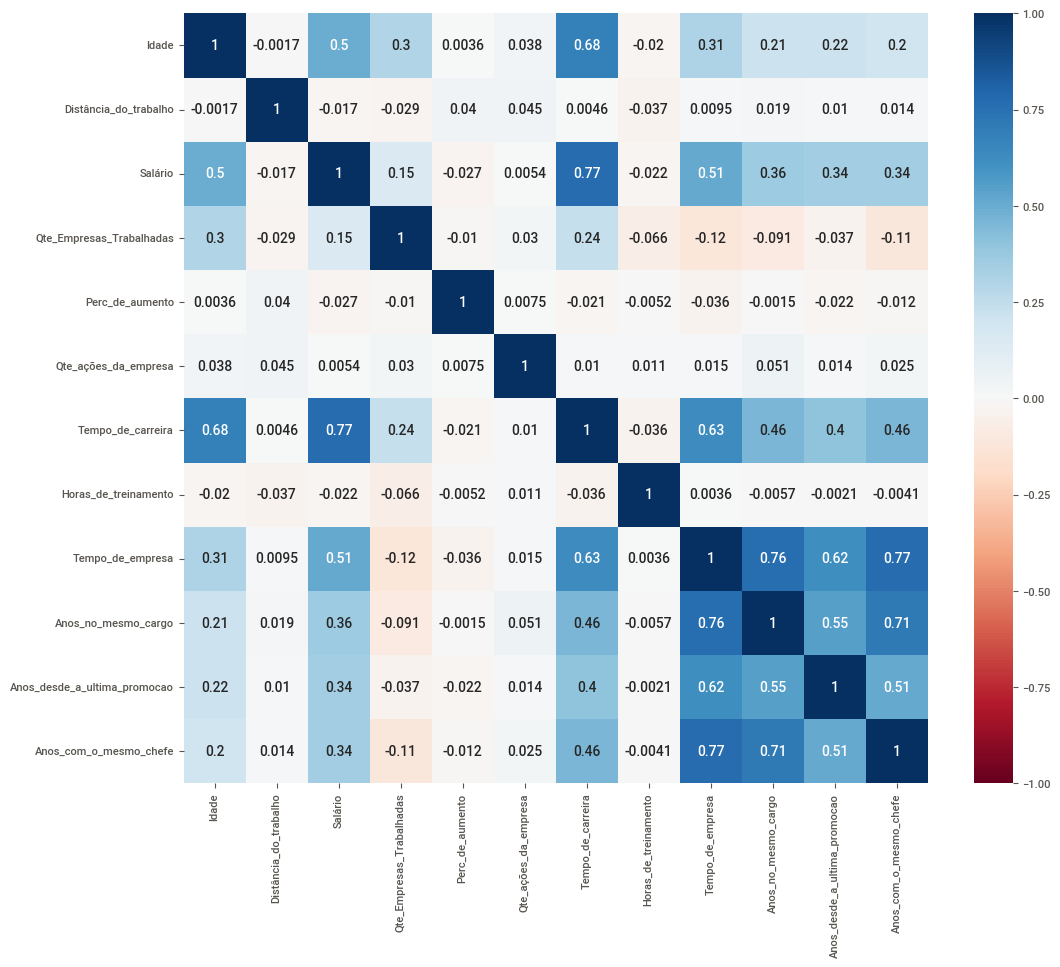

In [149]:
# Filtra apenas as colunas do tipo "int64" (ou seja, colunas numéricas)
df4 = df.loc[ : ,  df.dtypes == 'int64']

#Monta a matriz de correlação dropando a coluna ID e chamando o método corr
matriz_correlacao = df4.drop("ID",axis = 1).corr()

matriz_correlacao

#ajusta o tamanho da figura
plt.figure(figsize=(12,10))

#troca a cor e coloca o valor da correlação dentro da matriz
sns.heatmap(matriz_correlacao, cmap='RdBu', annot=True, vmin=-1, vmax=1);